<a href="https://colab.research.google.com/github/Jyoti15-star/week-2-assignment-1/blob/main/Week2Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Part A: Dataset Understanding

### Q1. Load the dataset and display the first five records.

In [7]:
import pandas as pd

df = pd.read_csv('Dataset 2.csv')
display(df.head())

,UserID,Age,Gender,SubscriptionType,WatchHoursPerWeek,DevicesUsed,FavoriteGenre,AdClicks,MonthlySpend,SubscriptionRenewed
0,1001,22,Female,Basic,23,5,Comedy,13,353,No
1,1002,55,Male,Basic,9,4,Drama,14,317,Yes
2,1003,49,Male,Basic,8,3,Comedy,16,309,No
3,1004,39,Female,Premium,19,5,Drama,45,833,Yes
4,1005,38,Female,Premium,23,5,Sci-Fi,24,804,Yes


### Q2. Determine the number of rows and columns in the dataset.

In [ ]:
num_rows, num_cols = df.shape
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_cols}")

Number of rows: 750
Number of columns: 10


### Q3. Display all column names.

In [ ]:
print("Column names:")
print(df.columns)

Column names:
Index(['UserID', 'Age', 'Gender', 'SubscriptionType', 'WatchHoursPerWeek',
       'DevicesUsed', 'FavoriteGenre', 'AdClicks', 'MonthlySpend',
       'SubscriptionRenewed'],
      dtype='object')


### Q4. Identify numerical and categorical features.

In [ ]:
numerical_features = df.select_dtypes(include=['number']).columns.tolist()
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numerical Features: {numerical_features}")
print(f"Categorical Features: {categorical_features}")

Numerical Features: ['UserID', 'Age', 'WatchHoursPerWeek', 'DevicesUsed', 'AdClicks', 'MonthlySpend']
Categorical Features: ['Gender', 'SubscriptionType', 'FavoriteGenre', 'SubscriptionRenewed']


### Q5. Check whether the dataset contains missing values.

In [ ]:
missing_values = df.isnull().sum()
print("Missing values per column:")
display(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("\nThere are no missing values in the dataset.")
else:
    print("\nThere are missing values in the dataset.")

Missing values per column:


,0



There are no missing values in the dataset.


## Part B: Exploratory Data Analysis

### Q6. Calculate the average age of users.

In [8]:
average_age = df['Age'].mean()
print(f"Average age of users: {average_age:.2f}")

Average age of users: 41.82


### Q7. Determine the average watch hours per week.

In [9]:
average_watch_hours = df['WatchHoursPerWeek'].mean()
print(f"Average watch hours per week: {average_watch_hours:.2f}")

Average watch hours per week: 14.24


### Q8. Find the average monthly spending of users.

In [10]:
average_monthly_spend = df['MonthlySpend'].mean()
print(f"Average monthly spending of users: {average_monthly_spend:.2f}")

Average monthly spending of users: 689.91


### Q9. Count the number of users in each subscription category.

In [11]:
subscription_counts = df['SubscriptionType'].value_counts()
print("Number of users per subscription type:")
display(subscription_counts)

Number of users per subscription type:


,count
SubscriptionType,
Basic,342
Premium,279
VIP,129


### Q10. Determine the percentage of users who renewed their subscriptions.

In [12]:
renewal_percentage = df['SubscriptionRenewed'].value_counts(normalize=True) * 100
print("Percentage of users who renewed their subscriptions:")
display(renewal_percentage)

Percentage of users who renewed their subscriptions:


,proportion
SubscriptionRenewed,
No,53.733333
Yes,46.266667


## Part C: Data Preparation

### Q11. Convert categorical features into numerical form.

In [13]:
categorical_cols = ['Gender', 'SubscriptionType', 'FavoriteGenre']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("DataFrame after one-hot encoding:")
display(df_encoded.head())

DataFrame after one-hot encoding:


,UserID,Age,WatchHoursPerWeek,DevicesUsed,AdClicks,MonthlySpend,SubscriptionRenewed,Gender_Male,SubscriptionType_Premium,SubscriptionType_VIP,FavoriteGenre_Comedy,FavoriteGenre_Drama,FavoriteGenre_Horror,FavoriteGenre_Romance,FavoriteGenre_Sci-Fi
0,1001,22,23,5,13,353,No,False,False,False,True,False,False,False,False
1,1002,55,9,4,14,317,Yes,True,False,False,False,True,False,False,False
2,1003,49,8,3,16,309,No,True,False,False,True,False,False,False,False
3,1004,39,19,5,45,833,Yes,False,True,False,False,True,False,False,False
4,1005,38,23,5,24,804,Yes,False,True,False,False,False,False,False,True


### Q12. Define the feature set (X) and target variable (y) for subscription renewal prediction.

In [14]:
y = df_encoded['SubscriptionRenewed']

X = df_encoded.drop(columns=['UserID', 'SubscriptionRenewed'])

print("Features (X) head:")
display(X.head())
print("\nTarget variable (y) head:")
display(y.head())

Features (X) head:


,Age,WatchHoursPerWeek,DevicesUsed,AdClicks,MonthlySpend,Gender_Male,SubscriptionType_Premium,SubscriptionType_VIP,FavoriteGenre_Comedy,FavoriteGenre_Drama,FavoriteGenre_Horror,FavoriteGenre_Romance,FavoriteGenre_Sci-Fi
0,22,23,5,13,353,False,False,False,True,False,False,False,False
1,55,9,4,14,317,True,False,False,False,True,False,False,False
2,49,8,3,16,309,True,False,False,True,False,False,False,False
3,39,19,5,45,833,False,True,False,False,True,False,False,False
4,38,23,5,24,804,False,True,False,False,False,False,False,True



Target variable (y) head:


,SubscriptionRenewed
0,No
1,Yes
2,No
3,Yes
4,Yes


### Q13. Split the dataset into training and testing sets.

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (600, 13)
X_test shape: (150, 13)
y_train shape: (600,)
y_test shape: (150,)


## Part D: Decision Tree Classification

### Q14. Train a Decision Tree model to predict whether a user will renew their subscription.

In [16]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully!")

Decision Tree Classifier trained successfully!


### Q15. Evaluate the model using accuracy.

In [17]:
from sklearn.metrics import accuracy_score
y_pred = dtc.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.5800


### Q16. Generate and interpret the confusion matrix.

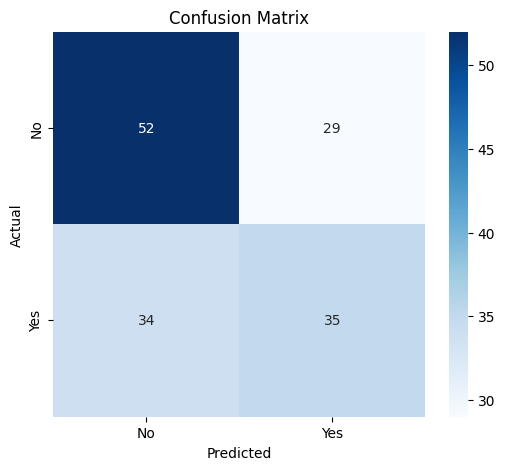

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=dtc.classes_, yticklabels=dtc.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#### Interpretation of the Confusion Matrix:

The confusion matrix provides insight into the performance of the classification model:

*   **True Positives (TP):** The number of instances where the model correctly predicted 'Yes' (renewed subscription).
*   **True Negatives (TN):** The number of instances where the model correctly predicted 'No' (did not renew subscription).
*   **False Positives (FP):** The number of instances where the model incorrectly predicted 'Yes' when the actual was 'No' (Type I error).
*   **False Negatives (FN):** The number of instances where the model incorrectly predicted 'No' when the actual was 'Yes' (Type II error).

From the matrix, we can observe the counts for each of these categories and understand where the model is performing well and where it is making errors.

## Part E: K-Nearest Neighbors (KNN)

### Q17. Train a KNN classifier with K = 5.

In [19]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)nn.fit(X_train, y_train)

print("K-Nearest Neighbors (KNN) classifier with K=5 trained successfully!")

K-Nearest Neighbors (KNN) classifier with K=5 trained successfully!


### Q18. Compare the accuracy of KNN with the Decision Tree model.

In [20]:
from sklearn.metrics import accuracy_score
y_pred_knn = knn.predict(X_test)
accuracy_knn = accuracy_score(y_test, y_pred_knn)

print(f"KNN Model Accuracy (K=5): {accuracy_knn:.4f}")
print(f"Decision Tree Model Accuracy: {accuracy:.4f}")

if accuracy_knn > accuracy:
    print(f"\nThe KNN model (Accuracy: {accuracy_knn:.4f}) performed better than the Decision Tree model (Accuracy: {accuracy:.4f}).")
elif accuracy_knn < accuracy:
    print(f"\nThe Decision Tree model (Accuracy: {accuracy:.4f}) performed better than the KNN model (Accuracy: {accuracy_knn:.4f}).")
else:
    print(f"\nBoth KNN and Decision Tree models achieved the same accuracy of {accuracy_knn:.4f}.")

KNN Model Accuracy (K=5): 0.5533
Decision Tree Model Accuracy: 0.5800

The Decision Tree model (Accuracy: 0.5800) performed better than the KNN model (Accuracy: 0.5533).


## Part F: Linear Regression

### Q19. Train a Linear Regression model to predict monthly spending.

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
X_lr = df_encoded.drop(columns=['UserID', 'MonthlySpend', 'SubscriptionRenewed'])
y_lr = df_encoded['MonthlySpend']
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_lr, y_lr, test_size=0.2, random_state=42)
lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train_lr)

print("Linear Regression model for Monthly Spending trained successfully!")

Linear Regression model for Monthly Spending trained successfully!


### Q20. Predict the monthly spending for a new user and interpret the result.

In [25]:
import numpy as np
new_user_data = {
    'Age': [30],
    'WatchHoursPerWeek': [15],
    'DevicesUsed': [3],
    'AdClicks': [20],
    'Gender_Male': [False],
    'SubscriptionType_Premium': [True],
    'SubscriptionType_VIP': [False],
    'FavoriteGenre_Comedy': [False],
    'FavoriteGenre_Drama': [True],
    'FavoriteGenre_Horror': [False],
    'FavoriteGenre_Romance': [False],
    'FavoriteGenre_Sci-Fi': [False]
}

new_user_df = pd.DataFrame(new_user_data, columns=X_lr.columns)
predicted_spending = lr_model.predict(new_user_df)

print(f"Predicted monthly spending for the new user: ${predicted_spending[0]:.2f}")
print("\nInterpretation:")
print(f"Based on the trained Linear Regression model, a new user with the specified characteristics (Age=30, 15 Watch Hours per Week, 3 Devices Used, 20 Ad Clicks, Female, Premium Subscription, and Favorite Genre Drama) is predicted to have a monthly spending of approximately ${predicted_spending[0]:.2f}.")
print("This prediction is an estimate derived from the patterns learned by the model from the existing dataset.")

Predicted monthly spending for the new user: $765.94

Interpretation:
Based on the trained Linear Regression model, a new user with the specified characteristics (Age=30, 15 Watch Hours per Week, 3 Devices Used, 20 Ad Clicks, Female, Premium Subscription, and Favorite Genre Drama) is predicted to have a monthly spending of approximately $765.94.
This prediction is an estimate derived from the patterns learned by the model from the existing dataset.
